In [23]:
import pandas as pd
import os
import sys
import json
from pathlib import Path
import numpy as np

# Notebook is in notebooks/, so repo root is parent
REPO_ROOT = Path.cwd().parent
SRC_PATH = REPO_ROOT / "src"

# Insert src at the front of sys.path so imports work
sys.path.insert(0, str(SRC_PATH))

In [24]:
# Get repo root relative to the current notebook
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Load static preprocessing config
config_path = os.path.join(repo_root, "configs", "xgboost_baseline_params.json")
with open(config_path, "r") as f:
    config = json.load(f)

# Set input and output directories
in_dir = os.path.join(repo_root, config["paths"]["in_dir"])

In [25]:
ed_vitals = pd.read_csv(os.path.join(in_dir, config["sources"]["vitals"]))
ed_vitals.head(5)

,subject_id,stay_id,charttime,temperature,heartrate,resprate,o2sat,sbp,dbp
0,17195991,38649090,2110-01-11 21:45:00,NaN,141.0,24.0,94.0,NaN,NaN
1,17195991,38649090,2110-01-11 21:50:00,NaN,123.0,24.0,91.0,151.0,120.0
2,17195991,38649090,2110-01-11 22:00:00,NaN,133.0,23.0,99.0,180.0,86.0
3,17195991,38649090,2110-01-11 22:07:00,NaN,164.0,24.0,99.0,198.0,116.0
4,17195991,38649090,2110-01-11 22:23:00,NaN,130.0,16.0,100.0,235.0,126.0


In [26]:
clinical_encounters = pd.read_csv(os.path.join(in_dir, config["sources"]["clinical_encounters"]), dtype=str, low_memory=False)
print(clinical_encounters.shape)
clinical_encounters.head(5)

(494231, 86)


,subject_id,hadm_id,ed_stay_id,ed_intime,ed_outtime,hosp_admittime,hosp_dischtime,race,gender,anchor_age,...,label_stemi,label_subsequent_mi,label_supraventricular_tachycardia,label_tia,label_unspecified_cardiac,label_unstable_angina,label_valvular_heart_disease,label_ventricular_arrhythmias,is_cardiovascular,is_specified_cardiac
0,10049341,20677333.0,34255415.0,2171-04-07 17:48:00,2171-04-08 09:31:00,2171-04-08 00:26:00,2171-04-08 09:31:00,ASIAN,F,55.0,...,0,0,0,0,0,0,0,0,0,0
1,10049341,NaN,35767475.0,2170-08-29 18:20:00,2170-08-29 22:46:00,NaN,NaN,ASIAN,F,NaN,...,0,0,0,0,0,0,0,0,0,0
2,10049341,NaN,36382949.0,2171-11-19 20:09:00,2171-11-20 00:03:00,NaN,NaN,ASIAN,F,NaN,...,0,0,0,0,0,0,0,0,0,0
3,10049341,NaN,36490047.0,2174-11-29 19:39:00,2174-11-30 00:49:00,NaN,NaN,ASIAN,F,NaN,...,0,0,0,0,0,0,0,0,0,0
4,10049341,NaN,37283116.0,2174-01-26 20:10:00,2174-01-27 00:34:00,NaN,NaN,ASIAN,F,NaN,...,0,0,0,0,0,0,0,0,0,0


In [27]:
ed_encounters = clinical_encounters[clinical_encounters['ed_stay_id'].notna()]
print(ed_encounters.shape)
ed_encounters.head(5)

(265702, 86)


,subject_id,hadm_id,ed_stay_id,ed_intime,ed_outtime,hosp_admittime,hosp_dischtime,race,gender,anchor_age,...,label_stemi,label_subsequent_mi,label_supraventricular_tachycardia,label_tia,label_unspecified_cardiac,label_unstable_angina,label_valvular_heart_disease,label_ventricular_arrhythmias,is_cardiovascular,is_specified_cardiac
0,10049341,20677333.0,34255415.0,2171-04-07 17:48:00,2171-04-08 09:31:00,2171-04-08 00:26:00,2171-04-08 09:31:00,ASIAN,F,55.0,...,0,0,0,0,0,0,0,0,0,0
1,10049341,NaN,35767475.0,2170-08-29 18:20:00,2170-08-29 22:46:00,NaN,NaN,ASIAN,F,NaN,...,0,0,0,0,0,0,0,0,0,0
2,10049341,NaN,36382949.0,2171-11-19 20:09:00,2171-11-20 00:03:00,NaN,NaN,ASIAN,F,NaN,...,0,0,0,0,0,0,0,0,0,0
3,10049341,NaN,36490047.0,2174-11-29 19:39:00,2174-11-30 00:49:00,NaN,NaN,ASIAN,F,NaN,...,0,0,0,0,0,0,0,0,0,0
4,10049341,NaN,37283116.0,2174-01-26 20:10:00,2174-01-27 00:34:00,NaN,NaN,ASIAN,F,NaN,...,0,0,0,0,0,0,0,0,0,0


In [28]:
# check label column if any label sum is 0 remove that column

def filter_label_columns(df: pd.DataFrame, prefix="label_"):
    # select columns that contain the prefix
    label_cols = [col for col in df.columns if prefix in col]
    print(f"Label columns: {label_cols}")
    
    # convert to numeric safely (non-numeric -> NaN -> 0)
    numeric_labels = df[label_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

    # compute sums
    col_sums = numeric_labels.sum()

    # drop columns whose sum == 0
    cols_to_drop = col_sums[col_sums == 0].index.tolist()

    return df.drop(columns=cols_to_drop)

ed_encounters = filter_label_columns(ed_encounters, prefix="label_")
ed_encounters.shape



Label columns: ['label_active_infection_nonsepsis', 'label_acute_heart_failure', 'label_acute_hypercapnic_respiratory_failure', 'label_acute_hypoxic_respiratory_failure', 'label_acute_kidney_injury', 'label_acute_on_chronic_heart_failure', 'label_anemia', 'label_aortic_disease', 'label_ards', 'label_asthma_exacerbation', 'label_atrial_fibrillation_flutter', 'label_atrioventricular_block', 'label_bradyarrhythmias_heart_block', 'label_bundle_branch_block', 'label_cardiac_arrest', 'label_cardiogenic_shock', 'label_cardiomegaly', 'label_cardiomyopathy', 'label_chronic_heart_failure', 'label_chronic_ischemic_heart_disease', 'label_chronic_kidney_disease', 'label_chronic_total_occlusion', 'label_copd_exacerbation', 'label_coronary_aneurysm_dissection', 'label_coronary_artery_disease', 'label_deep_vein_thrombosis', 'label_diabetes_mellitus', 'label_dialysis_dependence', 'label_electrolyte_disturbance', 'label_end_stage_heart_failure', 'label_endocarditis', 'label_gi_bleed_or_hepatic_failure',

(265702, 86)

In [29]:
ed_encounters.shape

(265702, 86)

In [30]:
ed_encounters.columns

Index(['subject_id', 'hadm_id', 'ed_stay_id', 'ed_intime', 'ed_outtime',
       'hosp_admittime', 'hosp_dischtime', 'race', 'gender', 'anchor_age',
       'death_time', 'icu_stay_id', 'icu_intime', 'icu_outtime', 'icu_count',
       'diagnosis', 'icd_codes', 'labels', 'label_active_infection_nonsepsis',
       'label_acute_heart_failure',
       'label_acute_hypercapnic_respiratory_failure',
       'label_acute_hypoxic_respiratory_failure', 'label_acute_kidney_injury',
       'label_acute_on_chronic_heart_failure', 'label_anemia',
       'label_aortic_disease', 'label_ards', 'label_asthma_exacerbation',
       'label_atrial_fibrillation_flutter', 'label_atrioventricular_block',
       'label_bradyarrhythmias_heart_block', 'label_bundle_branch_block',
       'label_cardiac_arrest', 'label_cardiogenic_shock', 'label_cardiomegaly',
       'label_cardiomyopathy', 'label_chronic_heart_failure',
       'label_chronic_ischemic_heart_disease', 'label_chronic_kidney_disease',
       'label_chro

In [31]:
ecg_data = pd.read_csv(os.path.join(in_dir, config["sources"]["ecg"]))
print(ecg_data.shape)
ecg_data.head(5)

(403121, 59)


,subject_id,study_id,file_name,ecg_time,path,hadm_id,ed_stay_id,icu_stay_id,in_hosp,in_ed,...,normal_ecg,borderline_ecg,abnormal_ecg,paced_rhythm,sinus_arrhythmia,undetermined_rhythm,wpw_pattern,technical_issue,pericarditis,electrolyte_abnormality
0,16598616,40000035,40000035,2126-04-01 19:32:00,files/p1659/p16598616/s40000035/40000035,26101986.0,32731561.0,NaN,0,1,...,0,0,1,0,0,0,0,0,0,0
1,18370366,40000084,40000084,2179-08-30 11:58:00,files/p1837/p18370366/s40000084/40000084,NaN,37736561.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
2,12576058,40000115,40000115,2163-04-17 16:45:00,files/p1257/p12576058/s40000115/40000115,NaN,36567247.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
3,14691089,40000143,40000143,2175-07-21 01:01:00,files/p1469/p14691089/s40000143/40000143,23760732.0,38981935.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
4,16089780,40000152,40000152,2137-01-29 19:08:00,files/p1608/p16089780/s40000152/40000152,NaN,31326149.0,NaN,0,1,...,0,1,0,0,0,0,0,0,0,0


In [32]:
ed_ecg_data = ecg_data[ecg_data['in_ed'] == 1]
print(ed_ecg_data.shape)
ed_ecg_data.head(5)

(158284, 59)


,subject_id,study_id,file_name,ecg_time,path,hadm_id,ed_stay_id,icu_stay_id,in_hosp,in_ed,...,normal_ecg,borderline_ecg,abnormal_ecg,paced_rhythm,sinus_arrhythmia,undetermined_rhythm,wpw_pattern,technical_issue,pericarditis,electrolyte_abnormality
0,16598616,40000035,40000035,2126-04-01 19:32:00,files/p1659/p16598616/s40000035/40000035,26101986.0,32731561.0,NaN,0,1,...,0,0,1,0,0,0,0,0,0,0
1,18370366,40000084,40000084,2179-08-30 11:58:00,files/p1837/p18370366/s40000084/40000084,NaN,37736561.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
2,12576058,40000115,40000115,2163-04-17 16:45:00,files/p1257/p12576058/s40000115/40000115,NaN,36567247.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
3,14691089,40000143,40000143,2175-07-21 01:01:00,files/p1469/p14691089/s40000143/40000143,23760732.0,38981935.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
4,16089780,40000152,40000152,2137-01-29 19:08:00,files/p1608/p16089780/s40000152/40000152,NaN,31326149.0,NaN,0,1,...,0,1,0,0,0,0,0,0,0,0


In [33]:
ed_ecg_data.columns

Index(['subject_id', 'study_id', 'file_name', 'ecg_time', 'path', 'hadm_id',
       'ed_stay_id', 'icu_stay_id', 'in_hosp', 'in_ed', 'in_icu',
       'icu_within_12hrs', 'icu_within_24hrs', 'cart_id', 'bandwidth',
       'filtering', 'rr_interval', 'p_onset', 'p_end', 'qrs_onset', 'qrs_end',
       't_end', 'p_axis', 'qrs_axis', 't_axis', 'full_report', 'sinus_rhythm',
       'sinus_bradycardia', 'sinus_tachycardia', 'atrial_fibrillation',
       'atrial_flutter', 'tachyarrhythmia', 'other_rhythm',
       'right_bundle_branch_block', 'left_bundle_branch_block',
       'conduction_abnormality', 'left_anterior_fascicular_block',
       'left_ventricular_hypertrophy', 'right_ventricular_hypertrophy',
       'atrial_abnormality', 'axis_deviation', 'qrs_voltage_abnormality',
       'st_segment_abnormality', 't_wave_abnormality', 'qt_abnormality',
       'acute_ischemia', 'infarct_pattern', 'ventricular_ectopy',
       'supraventricular_ectopy', 'normal_ecg', 'borderline_ecg',
       'abnorm

In [34]:
machine_report_cols = ed_ecg_data.columns[26:]

# convert to numeric safely (non-numeric -> NaN -> 0)
numeric_labels = ed_ecg_data[machine_report_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# compute sums
col_sums = numeric_labels.sum()

# drop columns whose sum == 0
cols_to_drop = col_sums[col_sums == 0].index.tolist()

cleaned_ecg_data = ed_ecg_data.drop(columns=cols_to_drop)


In [35]:
cleaned_ecg_data.shape

(158284, 53)

In [36]:
cleaned_ecg_data.columns

Index(['subject_id', 'study_id', 'file_name', 'ecg_time', 'path', 'hadm_id',
       'ed_stay_id', 'icu_stay_id', 'in_hosp', 'in_ed', 'in_icu',
       'icu_within_12hrs', 'icu_within_24hrs', 'cart_id', 'bandwidth',
       'filtering', 'rr_interval', 'p_onset', 'p_end', 'qrs_onset', 'qrs_end',
       't_end', 'p_axis', 'qrs_axis', 't_axis', 'full_report', 'sinus_rhythm',
       'sinus_bradycardia', 'sinus_tachycardia', 'atrial_fibrillation',
       'atrial_flutter', 'tachyarrhythmia', 'other_rhythm',
       'right_bundle_branch_block', 'left_bundle_branch_block',
       'conduction_abnormality', 'left_anterior_fascicular_block',
       'left_ventricular_hypertrophy', 'right_ventricular_hypertrophy',
       'atrial_abnormality', 'axis_deviation', 'qt_abnormality',
       'ventricular_ectopy', 'supraventricular_ectopy', 'normal_ecg',
       'borderline_ecg', 'abnormal_ecg', 'paced_rhythm', 'sinus_arrhythmia',
       'undetermined_rhythm', 'wpw_pattern', 'technical_issue',
       'electroly

In [37]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    roc_auc_score, 
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# Define ECG feature columns (numeric measurements)
ecg_feature_cols = [
    'rr_interval', 'p_onset', 'p_end', 'qrs_onset', 'qrs_end', 't_end',
    'p_axis', 'qrs_axis', 't_axis'
]

machine_report_cols = cleaned_ecg_data.columns[26:]

print(f"Number of ECG features: {len(ecg_feature_cols)}")
print(f"Number of machine report labels: {len(machine_report_cols)}")

Number of ECG features: 9
Number of machine report labels: 27


In [38]:
# Select relevant columns
X = cleaned_ecg_data[ecg_feature_cols]
y = cleaned_ecg_data[machine_report_cols]

# Check target distributions
print(f"\n{'='*70}")
print("Target Label Distributions:")
print(f"{'='*70}")
for col in machine_report_cols:
    n_pos = y[col].sum()
    pos_rate = y[col].mean()
    if n_pos < 1500:
        print(f"{col}: {int(n_pos)} cases ({pos_rate:.4%})")


Target Label Distributions:
atrial_flutter: 436 cases (0.2755%)
tachyarrhythmia: 247 cases (0.1560%)
other_rhythm: 495 cases (0.3127%)
conduction_abnormality: 279 cases (0.1763%)
right_ventricular_hypertrophy: 395 cases (0.2496%)
ventricular_ectopy: 536 cases (0.3386%)
supraventricular_ectopy: 319 cases (0.2015%)
paced_rhythm: 581 cases (0.3671%)
undetermined_rhythm: 168 cases (0.1061%)
wpw_pattern: 14 cases (0.0088%)
technical_issue: 217 cases (0.1371%)
electrolyte_abnormality: 4 cases (0.0025%)


Training set: 126627 samples
Test set: 31657 samples
Number of targets: 27

Top 10 labels:
                          label  train_count  test_count
0                  sinus_rhythm        74425       18640
1                  abnormal_ecg        27430        6778
2                borderline_ecg        18600        4639
3                    normal_ecg        14004        3539
4             sinus_tachycardia        12453        3267
5             sinus_bradycardia         9869        2366
6                axis_deviation         8002        1958
7           atrial_fibrillation         6287        1578
8  left_ventricular_hypertrophy         5977        1469
9                qt_abnormality         5329        1272


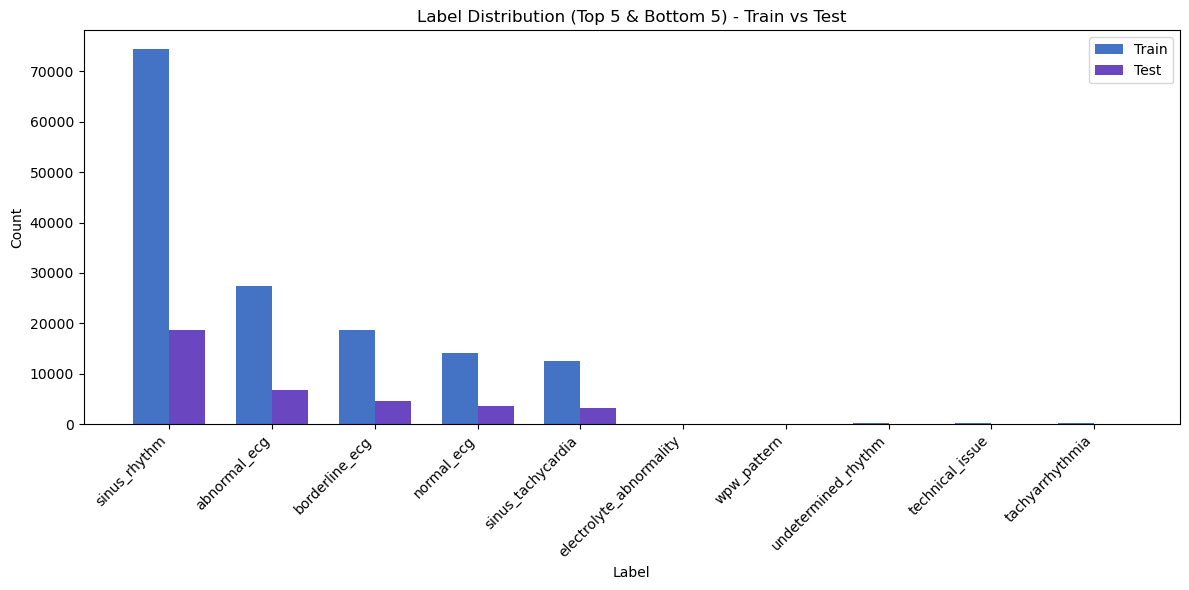

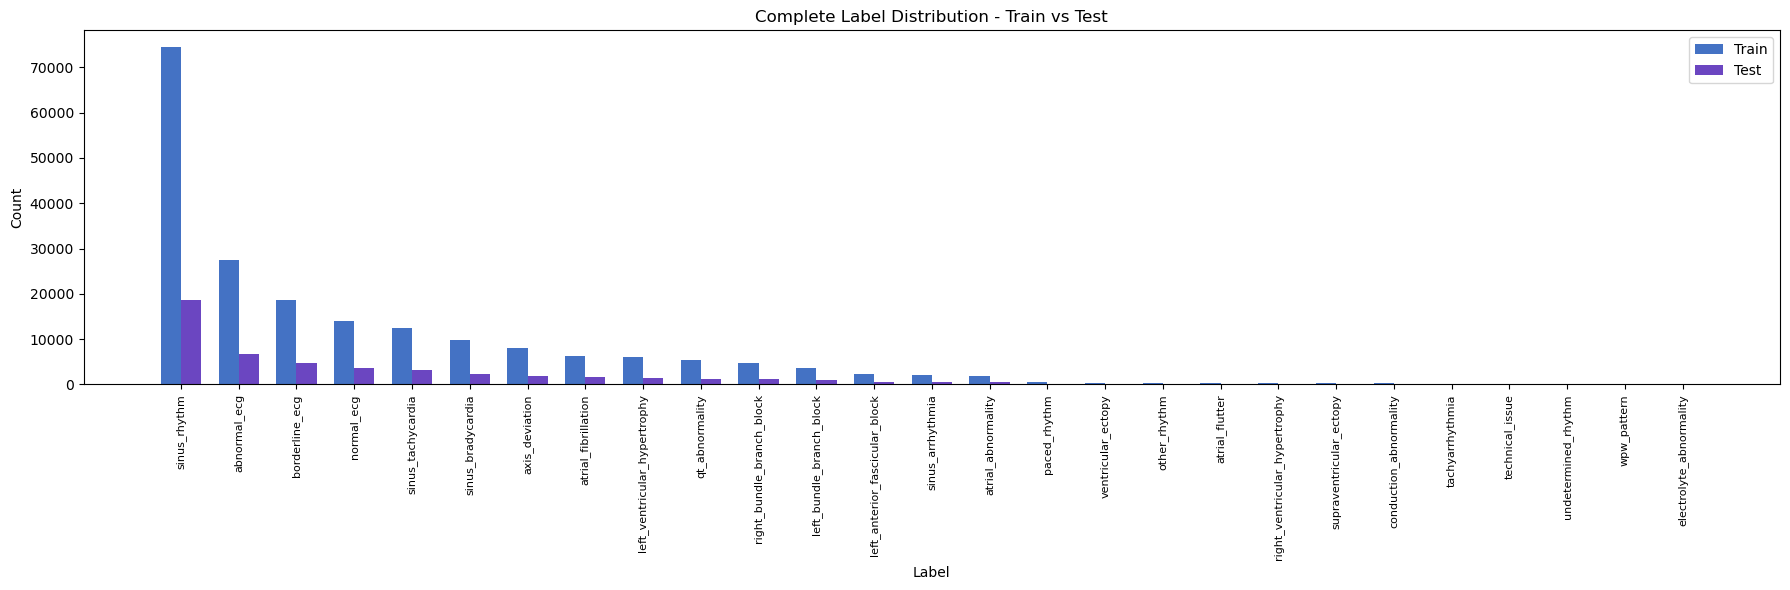


Train/Test split verification (first 5 labels):
sinus_rhythm: Train=80.0%, Test=20.0%
abnormal_ecg: Train=80.2%, Test=19.8%
borderline_ecg: Train=80.0%, Test=20.0%
normal_ecg: Train=79.8%, Test=20.2%
sinus_tachycardia: Train=79.2%, Test=20.8%


In [39]:
# Train-test split (80/20 random split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Number of targets: {y_train.shape[1]}")

# Calculate label counts for train and test
train_counts = y_train.sum().sort_values(ascending=False)
test_counts = y_test.sum().sort_values(ascending=False)

# Create DataFrame for plotting
label_df = pd.DataFrame({
    'label': train_counts.index,
    'train_count': train_counts.values,
    'test_count': test_counts.values
})

# Display top 10 labels
print("\nTop 10 labels:")
print(label_df.head(10))

# Get top 5 and bottom 5 labels by total count
label_df['total_count'] = label_df['train_count'] + label_df['test_count']
top_bottom_df = pd.concat([
    label_df.nlargest(5, 'total_count'),
    label_df.nsmallest(5, 'total_count')
])

# Plot top 5 and bottom 5 (train vs test)
plt.figure(figsize=(12, 6))
x = np.arange(len(top_bottom_df))
width = 0.35

plt.bar(x - width/2, top_bottom_df['train_count'], width, 
        label='Train', color='#4472C4')
plt.bar(x + width/2, top_bottom_df['test_count'], width, 
        label='Test', color='#6B46C1')

plt.xticks(x, top_bottom_df['label'], rotation=45, ha='right')
plt.title("Label Distribution (Top 5 & Bottom 5) - Train vs Test")
plt.ylabel("Count")
plt.xlabel("Label")
plt.legend()
plt.tight_layout()
plt.show()

# Plot all labels (train vs test)
plt.figure(figsize=(18, 6))
x = np.arange(len(label_df))
width = 0.35

plt.bar(x - width/2, label_df['train_count'], width, 
        label='Train', color='#4472C4')
plt.bar(x + width/2, label_df['test_count'], width, 
        label='Test', color='#6B46C1')

plt.xticks(x, label_df['label'], rotation=90, fontsize=8)
plt.title("Complete Label Distribution - Train vs Test")
plt.ylabel("Count")
plt.xlabel("Label")
plt.legend()
plt.tight_layout()
plt.show()

# Verify split ratios
print("\nTrain/Test split verification (first 5 labels):")
for label in label_df['label'][:5]:
    train_pct = label_df[label_df['label'] == label]['train_count'].values[0] / label_df[label_df['label'] == label]['total_count'].values[0] * 100
    test_pct = label_df[label_df['label'] == label]['test_count'].values[0] / label_df[label_df['label'] == label]['total_count'].values[0] * 100
    print(f"{label}: Train={train_pct:.1f}%, Test={test_pct:.1f}%")

In [40]:
from sklearn.multioutput import MultiOutputClassifier

# Train MultiOutputClassifier for all 22 machine reports
print("Training MultiOutputClassifier for 22 machine reports...")
print("This will train 22 separate XGBoost models (one per label)")
print(f"{'='*70}\n")

multi_xgb = MultiOutputClassifier(
    XGBClassifier(
        max_depth=6,
        learning_rate=0.1,
        n_estimators=100,
        tree_method='hist',
        random_state=42,
        n_jobs=1
    ),
    n_jobs=-1
)

# Fit the model
multi_xgb.fit(X_train, y_train)

print("\n✓ Training complete!")
print(f"Trained {len(multi_xgb.estimators_)} separate XGBoost models")

Training MultiOutputClassifier for 22 machine reports...
This will train 22 separate XGBoost models (one per label)



/Users/brandonng/miniforge3/envs/dsc180/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



✓ Training complete!
Trained 27 separate XGBoost models


In [41]:
# Evaluate performance for each of the 35 labels
print(f"\n{'='*70}")
print(f"PERFORMANCE FOR ALL {len(machine_report_cols)} MACHINE REPORTS")
print(f"{'='*70}\n")

results = []

for i, target in enumerate(machine_report_cols):
    # Get predictions for this specific label
    y_pred_proba = multi_xgb.estimators_[i].predict_proba(X_test)[:, 1]
    
    # Calculate metrics (only if both classes present in test set)
    n_pos_test = y_test[target].sum()
    n_test = len(y_test)
    
    if y_test[target].nunique() > 1:  # Both classes present
        auc = roc_auc_score(y_test[target], y_pred_proba)
        ap = average_precision_score(y_test[target], y_pred_proba)
    else:
        auc = np.nan
        ap = np.nan
    
    results.append({
        'target': target,
        'n_test_pos': int(n_pos_test),
        'pos_rate': y_test[target].mean(),
        'roc_auc': auc,
        'pr_auc': ap
    })
    
    # Print individual results
    print(f"{target}:")
    print(f"  Test positive: {int(n_pos_test)}/{n_test} ({y_test[target].mean():.4%})")
    if not np.isnan(auc):
        print(f"  ROC-AUC: {auc:.4f}")
        print(f"  PR-AUC:  {ap:.4f}")
    else:
        print(f"  Status: Single class in test set (cannot compute AUC)")
    print()

# Convert to DataFrame for analysis
results_df = pd.DataFrame(results)


PERFORMANCE FOR ALL 27 MACHINE REPORTS

sinus_rhythm:
  Test positive: 18640/31657 (58.8811%)
  ROC-AUC: 0.9591
  PR-AUC:  0.9589

sinus_bradycardia:
  Test positive: 2366/31657 (7.4739%)
  ROC-AUC: 0.9915
  PR-AUC:  0.8727

sinus_tachycardia:
  Test positive: 3267/31657 (10.3200%)
  ROC-AUC: 0.9961
  PR-AUC:  0.9570

atrial_fibrillation:
  Test positive: 1578/31657 (4.9847%)
  ROC-AUC: 0.9800
  PR-AUC:  0.7989

atrial_flutter:
  Test positive: 87/31657 (0.2748%)
  ROC-AUC: 0.8873
  PR-AUC:  0.0321

tachyarrhythmia:
  Test positive: 52/31657 (0.1643%)
  ROC-AUC: 0.9972
  PR-AUC:  0.6034

other_rhythm:
  Test positive: 101/31657 (0.3190%)
  ROC-AUC: 0.9557
  PR-AUC:  0.1705

right_bundle_branch_block:
  Test positive: 1193/31657 (3.7685%)
  ROC-AUC: 0.9884
  PR-AUC:  0.7795

left_bundle_branch_block:
  Test positive: 909/31657 (2.8714%)
  ROC-AUC: 0.9815
  PR-AUC:  0.6701

conduction_abnormality:
  Test positive: 51/31657 (0.1611%)
  ROC-AUC: 0.9793
  PR-AUC:  0.1489

left_anterior_fas

In [42]:
# Summary statistics
print(f"\n{'='*70}")
print("SUMMARY STATISTICS")
print(f"{'='*70}")

valid_results = results_df[results_df['roc_auc'].notna()]

print(f"\nLabels with valid metrics: {len(valid_results)}/{len(results_df)}")
print(f"Mean ROC-AUC: {valid_results['roc_auc'].mean():.4f}")
print(f"Median ROC-AUC: {valid_results['roc_auc'].median():.4f}")
print(f"Mean PR-AUC: {valid_results['pr_auc'].mean():.4f}")
print(f"Median PR-AUC: {valid_results['pr_auc'].median():.4f}")

print(f"\nTop 10 Best Performing Labels (by ROC-AUC):")
print(valid_results.nlargest(10, 'roc_auc')[['target', 'n_test_pos', 'roc_auc', 'pr_auc']].to_string(index=False))

print(f"\nBottom 10 Worst Performing Labels (by ROC-AUC):")
print(valid_results.nsmallest(10, 'roc_auc')[['target', 'n_test_pos', 'roc_auc', 'pr_auc']].to_string(index=False))


SUMMARY STATISTICS

Labels with valid metrics: 26/27
Mean ROC-AUC: 0.9412
Median ROC-AUC: 0.9725
Mean PR-AUC: 0.4891
Median PR-AUC: 0.5775

Top 10 Best Performing Labels (by ROC-AUC):
                        target  n_test_pos  roc_auc   pr_auc
               technical_issue          32 0.999919 0.977522
               tachyarrhythmia          52 0.997186 0.603393
                  paced_rhythm         118 0.996498 0.484926
             sinus_tachycardia        3267 0.996064 0.956974
                qt_abnormality        1272 0.991973 0.861409
             sinus_bradycardia        2366 0.991517 0.872704
left_anterior_fascicular_block         599 0.990776 0.551652
                axis_deviation        1958 0.990120 0.856897
           undetermined_rhythm          38 0.989403 0.148678
     right_bundle_branch_block        1193 0.988422 0.779504

Bottom 10 Worst Performing Labels (by ROC-AUC):
                       target  n_test_pos  roc_auc   pr_auc
             sinus_arrhythmia      

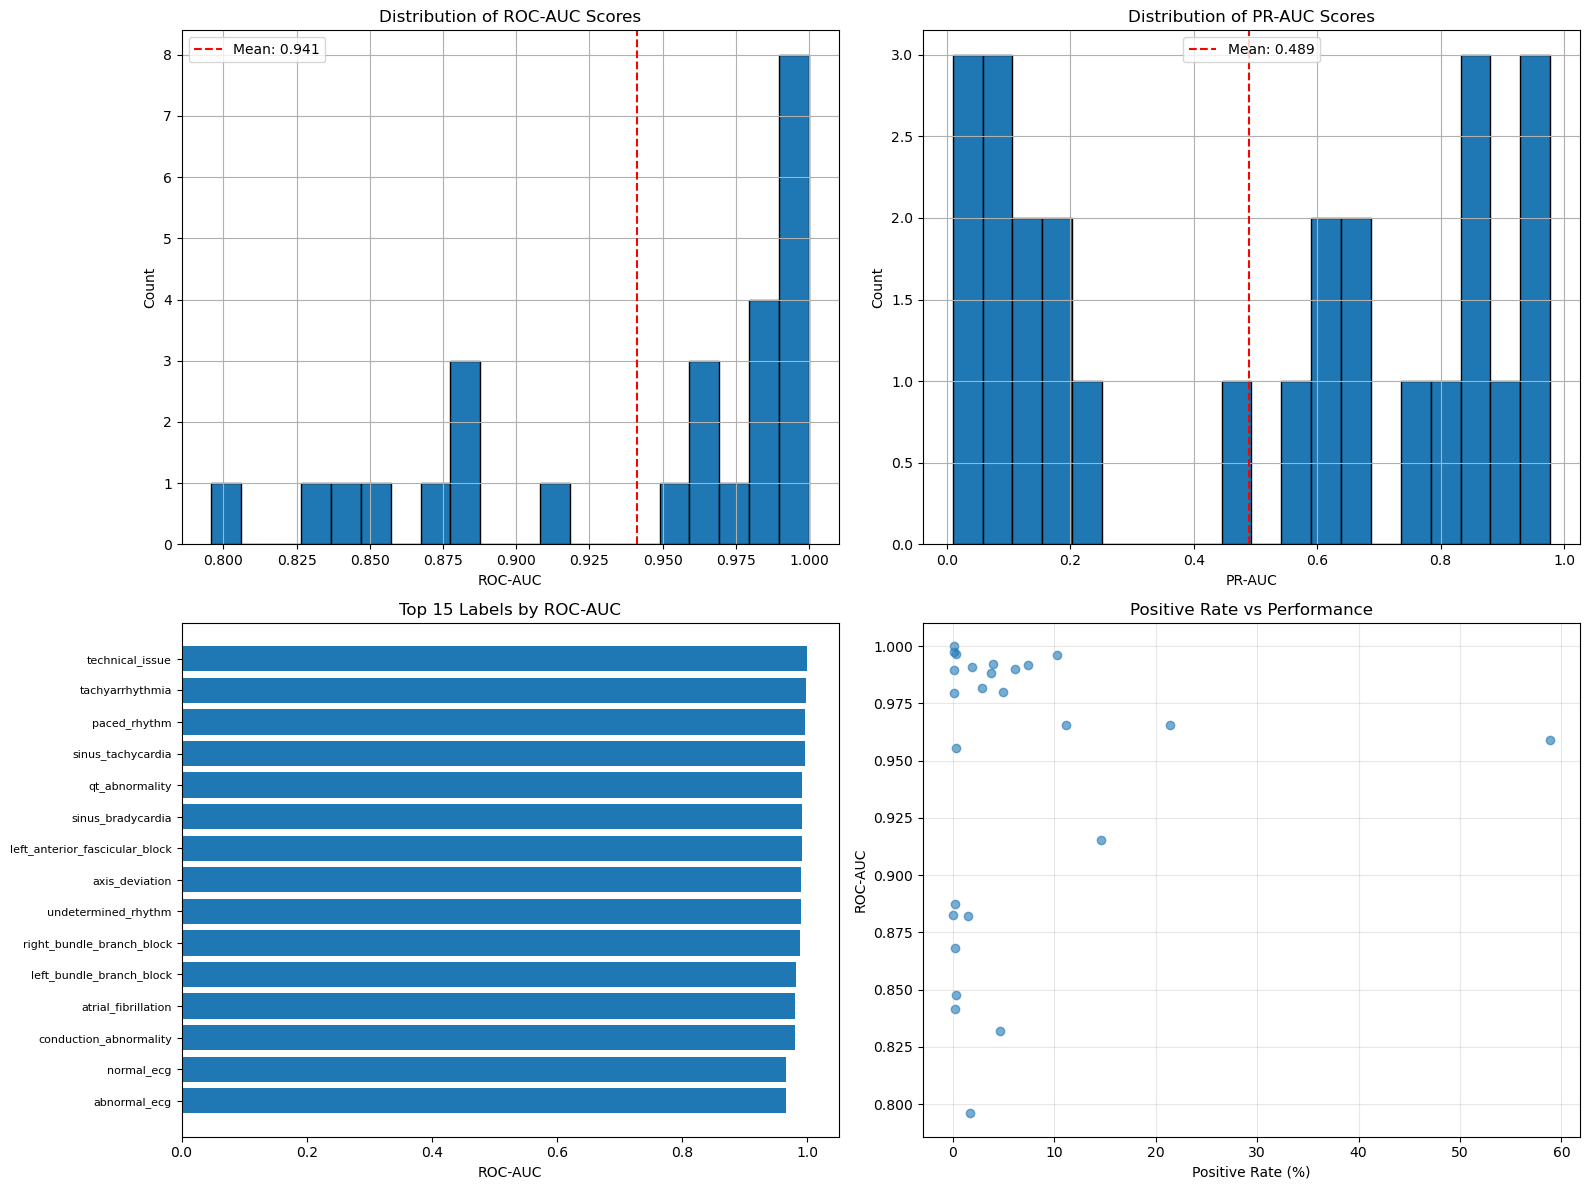

In [43]:
# Visualize performance across all labels
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. ROC-AUC distribution
valid_results['roc_auc'].hist(bins=20, ax=axes[0, 0], edgecolor='black')
axes[0, 0].set_xlabel('ROC-AUC')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Distribution of ROC-AUC Scores')
axes[0, 0].axvline(valid_results['roc_auc'].mean(), color='red', linestyle='--', label=f"Mean: {valid_results['roc_auc'].mean():.3f}")
axes[0, 0].legend()

# 2. PR-AUC distribution
valid_results['pr_auc'].hist(bins=20, ax=axes[0, 1], edgecolor='black')
axes[0, 1].set_xlabel('PR-AUC')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Distribution of PR-AUC Scores')
axes[0, 1].axvline(valid_results['pr_auc'].mean(), color='red', linestyle='--', label=f"Mean: {valid_results['pr_auc'].mean():.3f}")
axes[0, 1].legend()

# 3. Top 15 labels by ROC-AUC
top_15 = valid_results.nlargest(15, 'roc_auc')
axes[1, 0].barh(range(len(top_15)), top_15['roc_auc'])
axes[1, 0].set_yticks(range(len(top_15)))
axes[1, 0].set_yticklabels(top_15['target'], fontsize=8)
axes[1, 0].set_xlabel('ROC-AUC')
axes[1, 0].set_title('Top 15 Labels by ROC-AUC')
axes[1, 0].invert_yaxis()

# 4. Positive rate vs ROC-AUC
axes[1, 1].scatter(valid_results['pos_rate']*100, valid_results['roc_auc'], alpha=0.6)
axes[1, 1].set_xlabel('Positive Rate (%)')
axes[1, 1].set_ylabel('ROC-AUC')
axes[1, 1].set_title('Positive Rate vs Performance')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Visualizing: ['technical_issue', 'normal_ecg', 'sinus_arrhythmia']


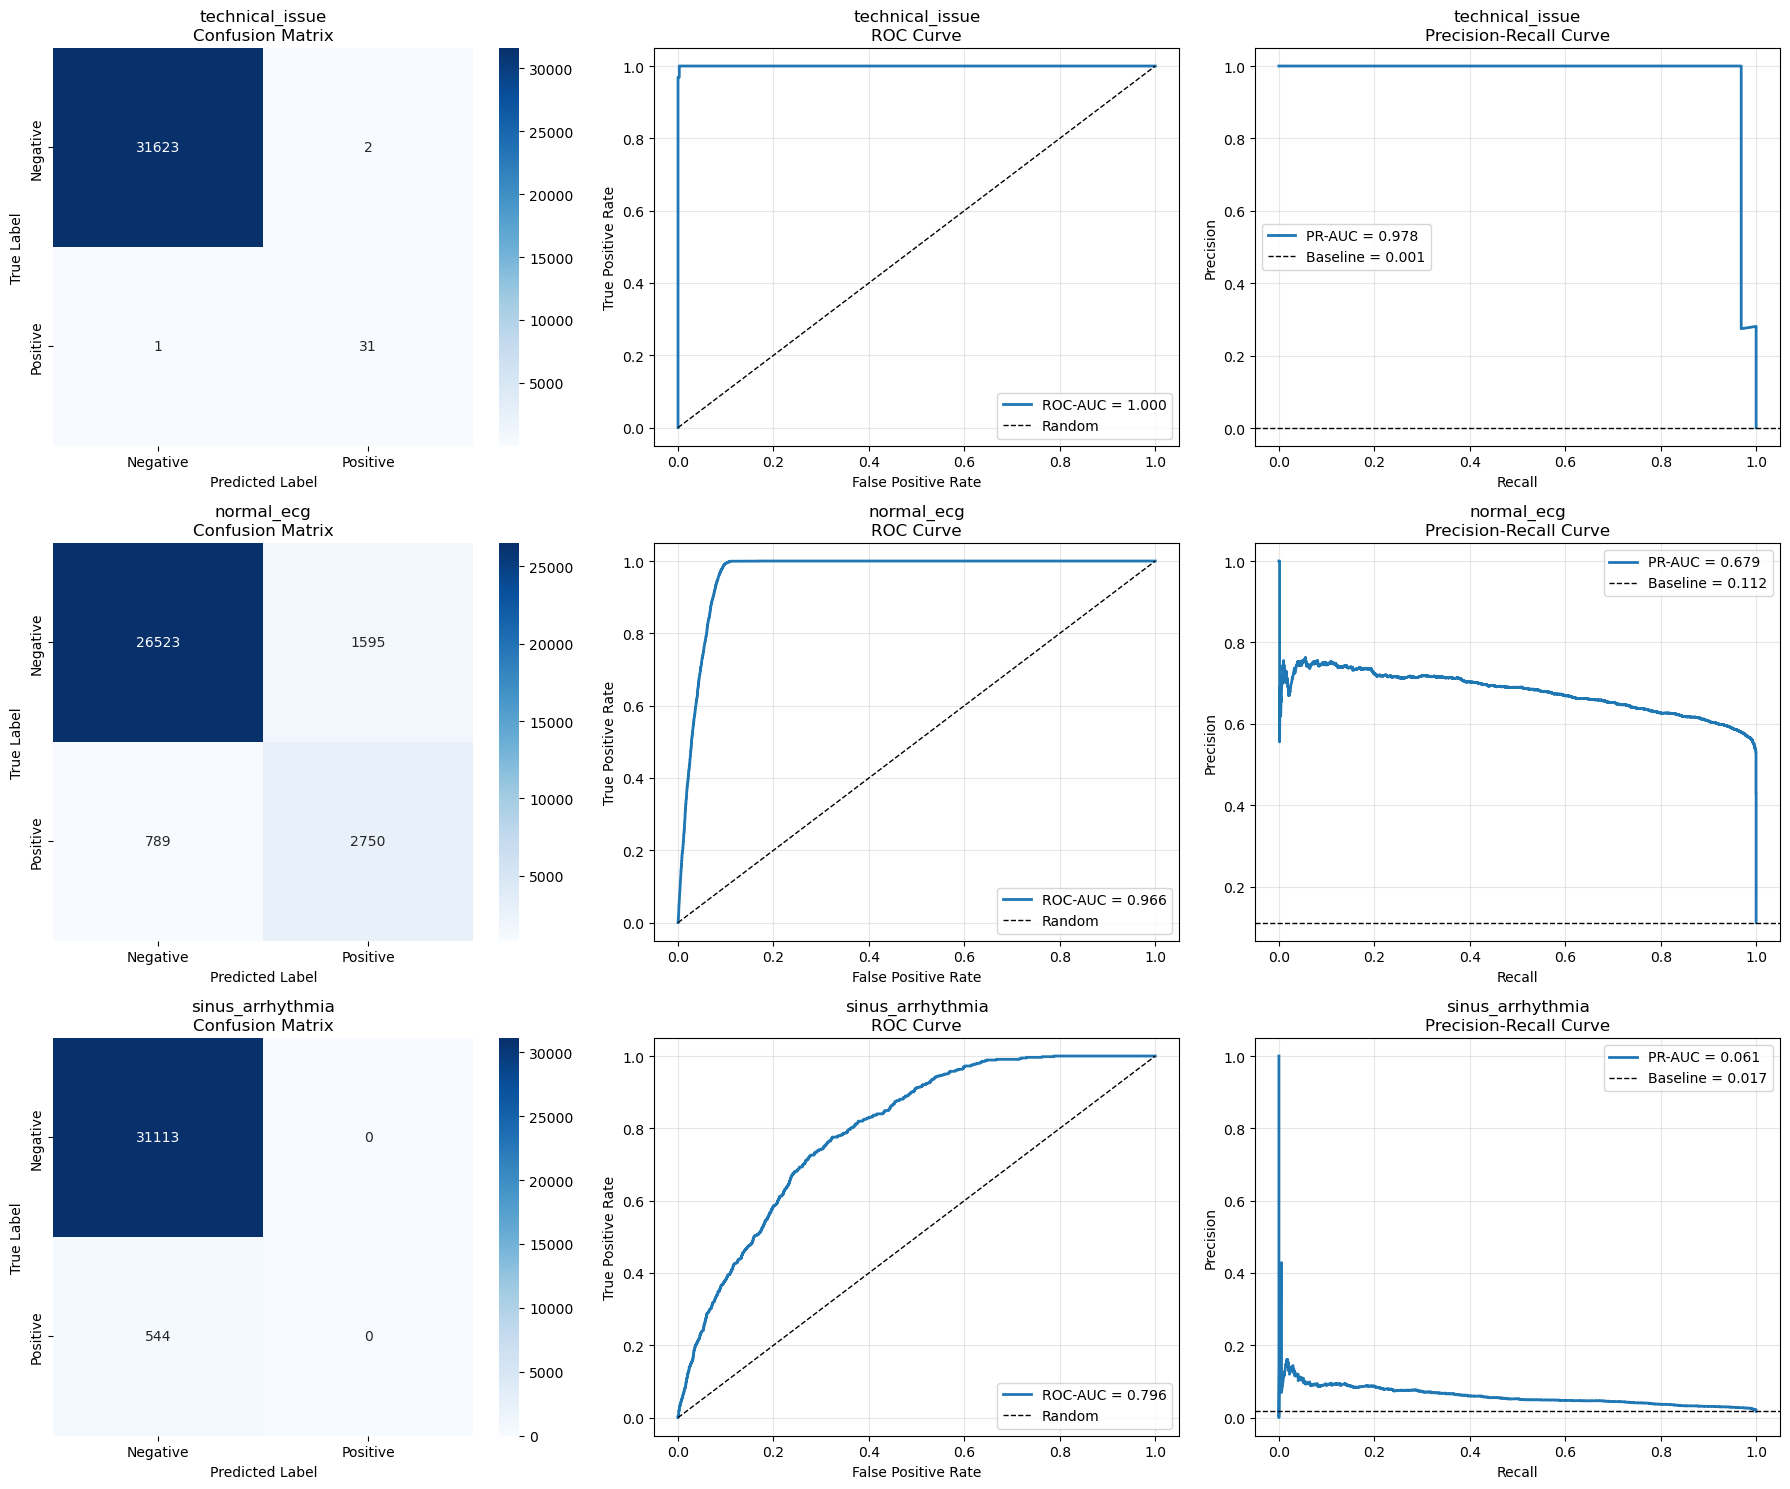


Visualized labels:
  Best:   technical_issue (ROC-AUC: 1.000)
  Medium: normal_ecg (ROC-AUC: 0.966)
  Worst:  sinus_arrhythmia (ROC-AUC: 0.796)


In [44]:
# Select a few representative labels to visualize
# Choose: best performer, worst performer, and a medium performer
valid_results_sorted = results_df[results_df['roc_auc'].notna()].sort_values('roc_auc', ascending=False)

best_label = valid_results_sorted.iloc[0]['target']
worst_label = valid_results_sorted.iloc[-1]['target']
medium_label = valid_results_sorted.iloc[len(valid_results_sorted)//2]['target']

selected_labels = [best_label, medium_label, worst_label]
print(f"Visualizing: {selected_labels}")

# Convert to list if needed
machine_report_cols_list = list(machine_report_cols)

# Create figure with 3 rows, 3 columns
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for row, label in enumerate(selected_labels):
    # Get index for this label
    label_idx = machine_report_cols_list.index(label)
    
    # Get predictions for this label
    y_true = y_test[label]
    y_pred = multi_xgb.estimators_[label_idx].predict(X_test)
    y_pred_proba = multi_xgb.estimators_[label_idx].predict_proba(X_test)[:, 1]
    
    # Get metrics
    label_metrics = results_df[results_df['target'] == label].iloc[0]
    roc_auc = label_metrics['roc_auc']
    pr_auc = label_metrics['pr_auc']
    
    # Column 1: Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, 0],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    axes[row, 0].set_title(f'{label}\nConfusion Matrix')
    axes[row, 0].set_ylabel('True Label')
    axes[row, 0].set_xlabel('Predicted Label')
    
    # Column 2: ROC Curve
    if y_true.nunique() > 1:  # Only plot if both classes present
        fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
        axes[row, 1].plot(fpr, tpr, linewidth=2, label=f'ROC-AUC = {roc_auc:.3f}')
        axes[row, 1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
        axes[row, 1].set_xlabel('False Positive Rate')
        axes[row, 1].set_ylabel('True Positive Rate')
        axes[row, 1].set_title(f'{label}\nROC Curve')
        axes[row, 1].legend(loc='lower right')
        axes[row, 1].grid(True, alpha=0.3)
    else:
        axes[row, 1].text(0.5, 0.5, 'Single class\nin test set', 
                         ha='center', va='center', fontsize=12)
        axes[row, 1].set_title(f'{label}\nROC Curve (N/A)')
    
    # Column 3: Precision-Recall Curve
    if y_true.nunique() > 1:  # Only plot if both classes present
        precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
        baseline_precision = y_true.mean()
        axes[row, 2].plot(recall, precision, linewidth=2, label=f'PR-AUC = {pr_auc:.3f}')
        axes[row, 2].axhline(baseline_precision, color='k', linestyle='--', 
                            linewidth=1, label=f'Baseline = {baseline_precision:.3f}')
        axes[row, 2].set_xlabel('Recall')
        axes[row, 2].set_ylabel('Precision')
        axes[row, 2].set_title(f'{label}\nPrecision-Recall Curve')
        axes[row, 2].legend(loc='best')
        axes[row, 2].grid(True, alpha=0.3)
    else:
        axes[row, 2].text(0.5, 0.5, 'Single class\nin test set', 
                         ha='center', va='center', fontsize=12)
        axes[row, 2].set_title(f'{label}\nPR Curve (N/A)')

plt.tight_layout()
plt.show()

print(f"\nVisualized labels:")
print(f"  Best:   {best_label} (ROC-AUC: {valid_results_sorted.iloc[0]['roc_auc']:.3f})")
print(f"  Medium: {medium_label} (ROC-AUC: {valid_results_sorted.iloc[len(valid_results_sorted)//2]['roc_auc']:.3f})")
print(f"  Worst:  {worst_label} (ROC-AUC: {valid_results_sorted.iloc[-1]['roc_auc']:.3f})")

Plotting 26 labels with valid metrics


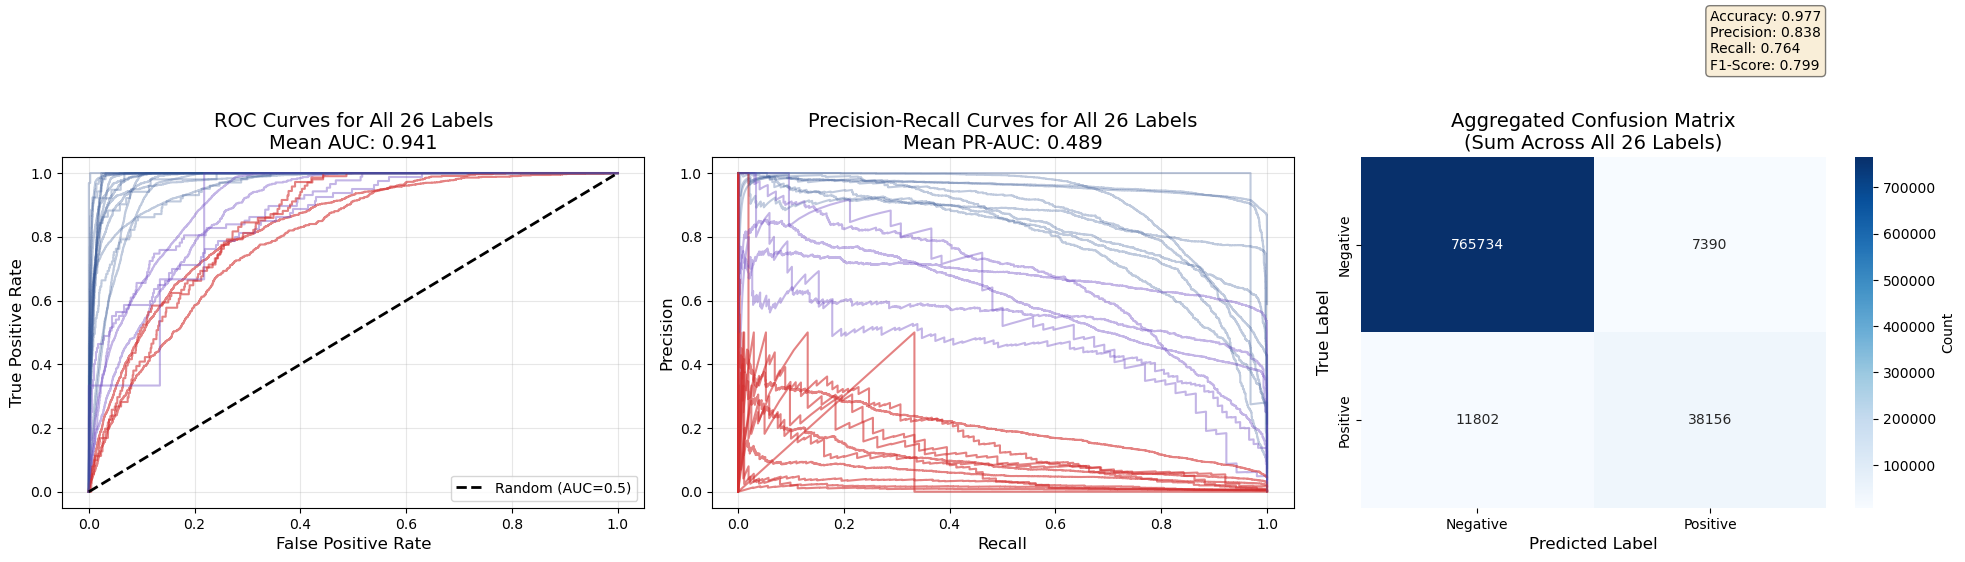


Aggregated Metrics (across all 26 labels):
  Total Predictions: 823082
  True Negatives:  765734 (93.0%)
  False Positives: 7390 (0.9%)
  False Negatives: 11802 (1.4%)
  True Positives:  38156 (4.6%)
  Overall Accuracy: 0.977
  Overall Precision: 0.838
  Overall Recall: 0.764
  Overall F1-Score: 0.799


In [45]:
# Get all valid labels (those with both classes in test set)
valid_labels = []
for label in machine_report_cols:
    if y_test[label].nunique() > 1:
        valid_labels.append(label)

print(f"Plotting {len(valid_labels)} labels with valid metrics")

# Create figure with 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: All ROC Curves ---
for i, label in enumerate(valid_labels):
    label_idx = list(machine_report_cols).index(label)
    y_true = y_test[label]
    y_pred_proba = multi_xgb.estimators_[label_idx].predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    label_metrics = results_df[results_df['target'] == label].iloc[0]
    roc_auc = label_metrics['roc_auc']
    
    # Use different colors for different performance levels
    if roc_auc >= 0.95:
        color = '#2E5090'  # Dark blue for excellent
        alpha = 0.3
    elif roc_auc >= 0.85:
        color = '#6B46C1'  # Purple for good
        alpha = 0.4
    else:
        color = '#D32F2F'  # Red for poor
        alpha = 0.6
    
    axes[0].plot(fpr, tpr, linewidth=1.5, alpha=alpha, color=color)

# Add random baseline and formatting
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title(f'ROC Curves for All {len(valid_labels)} Labels\nMean AUC: {results_df["roc_auc"].mean():.3f}', fontsize=14)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Plot 2: All Precision-Recall Curves ---
for i, label in enumerate(valid_labels):
    label_idx = list(machine_report_cols).index(label)
    y_true = y_test[label]
    y_pred_proba = multi_xgb.estimators_[label_idx].predict_proba(X_test)[:, 1]
    
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    label_metrics = results_df[results_df['target'] == label].iloc[0]
    pr_auc = label_metrics['pr_auc']
    
    # Use different colors for different performance levels
    if pr_auc >= 0.7:
        color = '#2E5090'  # Dark blue for excellent
        alpha = 0.3
    elif pr_auc >= 0.3:
        color = '#6B46C1'  # Purple for moderate
        alpha = 0.4
    else:
        color = '#D32F2F'  # Red for poor
        alpha = 0.6
    
    axes[1].plot(recall, precision, linewidth=1.5, alpha=alpha, color=color)

axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title(f'Precision-Recall Curves for All {len(valid_labels)} Labels\nMean PR-AUC: {results_df["pr_auc"].mean():.3f}', fontsize=14)
axes[1].grid(True, alpha=0.3)

# --- Plot 3: Aggregated Confusion Matrix (sum of all) ---
# Sum all confusion matrices
total_cm = np.zeros((2, 2))
for label in valid_labels:
    label_idx = list(machine_report_cols).index(label)
    y_true = y_test[label]
    y_pred = multi_xgb.estimators_[label_idx].predict(X_test)
    cm = confusion_matrix(y_true, y_pred)
    total_cm += cm

# Plot aggregated confusion matrix
sns.heatmap(total_cm, annot=True, fmt='.0f', cmap='Blues', ax=axes[2],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
axes[2].set_title(f'Aggregated Confusion Matrix\n(Sum Across All {len(valid_labels)} Labels)', fontsize=14)
axes[2].set_ylabel('True Label', fontsize=12)
axes[2].set_xlabel('Predicted Label', fontsize=12)

# Calculate overall metrics from aggregated CM
tn, fp, fn, tp = total_cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

# Add text with overall metrics
metrics_text = f'Accuracy: {accuracy:.3f}\nPrecision: {precision:.3f}\nRecall: {recall:.3f}\nF1-Score: {f1:.3f}'
axes[2].text(1.5, -0.5, metrics_text, fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\nAggregated Metrics (across all {len(valid_labels)} labels):")
print(f"  Total Predictions: {int(total_cm.sum())}")
print(f"  True Negatives:  {int(tn)} ({tn/total_cm.sum()*100:.1f}%)")
print(f"  False Positives: {int(fp)} ({fp/total_cm.sum()*100:.1f}%)")
print(f"  False Negatives: {int(fn)} ({fn/total_cm.sum()*100:.1f}%)")
print(f"  True Positives:  {int(tp)} ({tp/total_cm.sum()*100:.1f}%)")
print(f"  Overall Accuracy: {accuracy:.3f}")
print(f"  Overall Precision: {precision:.3f}")
print(f"  Overall Recall: {recall:.3f}")
print(f"  Overall F1-Score: {f1:.3f}")

In [47]:
# Save results to CSV for later analysis
results_df.to_csv('xgboost_baseline_results.csv', index=False)
print("Results saved to 'xgboost_baseline_results.csv'")

results_df_sorted = results_df.sort_values('pr_auc', ascending=False)
# Display full results DataFrame
print("\nFull Results:")
print(results_df_sorted.to_string(index=False))

Results saved to 'xgboost_baseline_results.csv'

Full Results:
                        target  n_test_pos  pos_rate  roc_auc   pr_auc
               technical_issue          32  0.001011 0.999919 0.977522
                  sinus_rhythm       18640  0.588811 0.959132 0.958895
             sinus_tachycardia        3267  0.103200 0.996064 0.956974
                  abnormal_ecg        6778  0.214107 0.965385 0.910580
             sinus_bradycardia        2366  0.074739 0.991517 0.872704
                qt_abnormality        1272  0.040181 0.991973 0.861409
                axis_deviation        1958  0.061850 0.990120 0.856897
           atrial_fibrillation        1578  0.049847 0.980018 0.798878
     right_bundle_branch_block        1193  0.037685 0.988422 0.779504
                    normal_ecg        3539  0.111792 0.965698 0.678604
      left_bundle_branch_block         909  0.028714 0.981540 0.670138
                borderline_ecg        4639  0.146539 0.915470 0.614375
              

The XGBoost baseline achieved strong overall discrimination across 21 machine-generated ECG report labels, with mean ROC-AUC (measuring how well the model ranks positive cases higher than negative cases across all thresholds) of 0.933 and mean PR-AUC (measuring how well the model finds positive cases without creating excessive false alarms, particularly important for imbalanced data) of 0.485. Common rhythm classifications showed excellent performance.However, rare conditions demonstrated the expected imbalanced-data challenge, showing substantially lower precision-recall performance despite moderate ROC-AUC scores (0.84-0.89), indicating that static ECG features alone struggle to identify these infrequent patterns. Overall impression labels (normal, borderline, abnormal ECG) achieved strong balanced performance (ROC-AUC: 0.92-0.97, PR-AUC: 0.61-0.91), validating that aggregate ECG measurements effectively capture overall cardiac abnormality and establishing a solid baseline (mean ROC-AUC: 0.933) for comparison with temporal deep learning models.